
# Metodologia resumida — elipsoides multivariados das forças de usinagem

Este notebook documenta, de forma compacta e reprodutível, a metodologia utilizada para relacionar a geometria tridimensional das forças de usinagem com a rugosidade média \(Ra\) no torneamento de Ti-6Al-4V.

O fluxo implementado é:

\[
\text{sinais }(F_c,F_f,F_p)
\rightarrow
\text{recorte dos transientes}
\rightarrow
\text{covariância 3D}
\rightarrow
\text{elipsoide}
\rightarrow
(a/b,\;b/c,\;d_M)
\rightarrow
\text{regressão OLS + LOOCV}.
\]

**Escopo atual.** A regressão final é reproduzida com a tabela processada dos 19 experimentos. Quando os CSVs dos sinais brutos forem adicionados a `data/raw/`, o mesmo notebook também poderá executar a extração das características desde as séries temporais.



## 1. Planejamento experimental e aquisição

O estudo foi conduzido com um Planejamento Composto Central, considerando:

- velocidade de corte \(V_c\);
- avanço \(f\);
- profundidade de corte \(a_p\);
- 19 experimentos, incluindo cinco repetições no ponto central.

Durante cada ensaio foram adquiridas simultaneamente as componentes:

\[
\mathbf{x}_i =
\begin{bmatrix}
F_{c,i} & F_{f,i} & F_{p,i}
\end{bmatrix}^{T},
\]

em que \(F_c\) é a força de corte, \(F_f\) é a força de avanço e \(F_p\) é a força passiva.

O código original adota intervalo de amostragem de \(0{,}002\ \mathrm{s}\), equivalente a \(500\ \mathrm{Hz}\). Para reduzir os transientes associados à entrada e à saída da ferramenta, são removidos 10% do início e 10% do final de cada sinal. Os 80% centrais restantes são analisados como uma única nuvem tridimensional por experimento.



## 2. Formulação geométrica

Para cada experimento, seja \(X\in\mathbb{R}^{n\times 3}\) a matriz com as observações de \(F_c\), \(F_f\) e \(F_p\).

### Centroide

\[
\boldsymbol{\mu}
=
\frac{1}{n}\sum_{i=1}^{n}\mathbf{x}_i.
\]

### Matriz de covariância amostral

\[
\boldsymbol{\Sigma}
=
\frac{1}{n-1}
\sum_{i=1}^{n}
(\mathbf{x}_i-\boldsymbol{\mu})
(\mathbf{x}_i-\boldsymbol{\mu})^T.
\]

### Decomposição espectral

\[
\boldsymbol{\Sigma}
=
\mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^{T},
\qquad
\lambda_1\geq\lambda_2\geq\lambda_3\geq 0.
\]

Os autovetores definem a orientação do elipsoide. Para uma região de 95% baseada na distribuição qui-quadrado com três graus de liberdade, os semieixos são:

\[
a=\sqrt{\chi^2_{3;0.95}\lambda_1},\qquad
b=\sqrt{\chi^2_{3;0.95}\lambda_2},\qquad
c=\sqrt{\chi^2_{3;0.95}\lambda_3}.
\]

As razões de forma utilizadas são:

\[
\frac{a}{b}
\quad\text{e}\quad
\frac{b}{c}.
\]

Como o mesmo multiplicador de confiança aparece em todos os semieixos, essas razões não dependem do nível de confiança escolhido.

### Distância de Mahalanobis do centroide à origem

\[
d_M
=
\sqrt{
\boldsymbol{\mu}^{T}
\boldsymbol{\Sigma}^{+}
\boldsymbol{\mu}
},
\]

em que \(\boldsymbol{\Sigma}^{+}\) é a pseudoinversa de Moore–Penrose.

> **Nota de interpretação:** \(d_M\) é uma distância adimensional na métrica induzida pela covariância. Ela representa o afastamento do centroide em relação à dispersão observada, mas não deve ser interpretada literalmente como energia física.


In [1]:
from pathlib import Path
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy import stats
from scipy.stats import chi2
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import LeaveOneOut
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore", category=FutureWarning)

# Localiza a raiz do repositório, independentemente de o notebook ser aberto
# na raiz ou dentro da pasta notebooks/.
START = Path.cwd().resolve()
ROOT = START
for candidate in [START, *START.parents]:
    if (candidate / "data" / "processed" / "experiment_summary.csv").exists():
        ROOT = candidate
        break

RAW_DIR = ROOT / "data" / "raw"
PROCESSED_FILE = ROOT / "data" / "processed" / "experiment_summary.csv"
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DT = 0.002
FS = 1 / DT
FRAC_INICIO = 0.10
FRAC_FIM = 0.10
NIVEL_CONFIANCA = 0.95
RANDOM_STATE = 42

print(f"Raiz do projeto: {ROOT}")
print(f"Frequência de amostragem assumida: {FS:.1f} Hz")


Raiz do projeto: /mnt/data/ti6al4v-force-ellipsoids
Frequência de amostragem assumida: 500.0 Hz



## 3. Leitura, padronização e recorte dos sinais

Os CSVs devem conter, no mínimo, as colunas correspondentes a `Fc`, `Ff` e `Fp`. A coluna de tempo é opcional.


In [2]:
def normalizar_nome_coluna(coluna: str) -> str:
    texto = str(coluna).strip().lower()
    for caractere in ["[", "]", "(", ")", "/", "_"]:
        texto = texto.replace(caractere, " ")
    return " ".join(texto.split())


def padronizar_colunas_forcas(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    mapa = {}

    for coluna in df.columns:
        nome = normalizar_nome_coluna(coluna)

        if nome in {"tempo s", "tempo", "time s", "time", "t", "t s"}:
            mapa[coluna] = "time"
        elif nome in {"fc n", "fc", "forca corte", "força corte", "corte"}:
            mapa[coluna] = "Fc"
        elif nome in {
            "ff n", "ff", "forca avanco", "força avanço", "avanco", "avanço"
        }:
            mapa[coluna] = "Ff"
        elif nome in {
            "fp n", "fp", "forca passiva", "força passiva", "passiva"
        }:
            mapa[coluna] = "Fp"

    df = df.rename(columns=mapa)

    faltantes = [col for col in ["Fc", "Ff", "Fp"] if col not in df.columns]
    if faltantes:
        raise ValueError(
            f"Colunas de força ausentes: {faltantes}. "
            f"Colunas encontradas: {list(df.columns)}"
        )

    if "time" not in df.columns:
        df["time"] = np.arange(len(df), dtype=float) * DT

    for coluna in ["time", "Fc", "Ff", "Fp"]:
        df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

    return (
        df.dropna(subset=["time", "Fc", "Ff", "Fp"])
        .reset_index(drop=True)[["time", "Fc", "Ff", "Fp"]]
    )


def recortar_sinal(
    df: pd.DataFrame,
    frac_inicio: float = FRAC_INICIO,
    frac_fim: float = FRAC_FIM,
) -> pd.DataFrame:
    if not 0 <= frac_inicio < 1 or not 0 <= frac_fim < 1:
        raise ValueError("As frações devem pertencer ao intervalo [0, 1).")
    if frac_inicio + frac_fim >= 1:
        raise ValueError("O recorte deve preservar uma fração positiva do sinal.")

    n = len(df)
    inicio = int(np.floor(frac_inicio * n))
    fim = int(np.ceil((1 - frac_fim) * n))

    if fim - inicio < 4:
        raise ValueError("O sinal recortado precisa conter pelo menos quatro pontos.")

    return df.iloc[inicio:fim].copy().reset_index(drop=True)



## 4. Extração das características do elipsoide 3D

A função abaixo executa o cálculo usado na metodologia final: centroide, covariância, decomposição espectral, semieixos, razões geométricas e distância de Mahalanobis.


In [3]:
def calcular_features_elipsoide_3d(
    df_sinal: pd.DataFrame,
    nivel_confianca: float = NIVEL_CONFIANCA,
    rcond: float = 1e-12,
) -> dict:
    X = df_sinal[["Fc", "Ff", "Fp"]].to_numpy(dtype=float)

    if X.ndim != 2 or X.shape[1] != 3 or len(X) < 4:
        raise ValueError("São necessárias pelo menos quatro observações tridimensionais.")
    if not np.isfinite(X).all():
        raise ValueError("O sinal contém valores não finitos.")

    mu = X.mean(axis=0)
    Sigma = np.cov(X, rowvar=False, ddof=1)

    autovalores, autovetores = np.linalg.eigh(Sigma)
    ordem = np.argsort(autovalores)[::-1]
    autovalores = np.clip(autovalores[ordem], 0.0, None)
    autovetores = autovetores[:, ordem]

    multiplicador = chi2.ppf(nivel_confianca, df=3)
    semieixos = np.sqrt(multiplicador * autovalores)
    a, b, c = semieixos

    eps = np.finfo(float).eps
    razao_a_b = a / max(b, eps)
    razao_b_c = b / max(c, eps)

    Sigma_inv = np.linalg.pinv(Sigma, rcond=rcond)
    dM2 = float(mu.T @ Sigma_inv @ mu)
    dM = float(np.sqrt(max(dM2, 0.0)))

    volume = float((4 / 3) * np.pi * a * b * c)

    return {
        "n_pontos": len(X),
        "Fc_mean": float(mu[0]),
        "Ff_mean": float(mu[1]),
        "Fp_mean": float(mu[2]),
        "lambda1": float(autovalores[0]),
        "lambda2": float(autovalores[1]),
        "lambda3": float(autovalores[2]),
        "semi_eixo_a": float(a),
        "semi_eixo_b": float(b),
        "semi_eixo_c": float(c),
        "razao_a_b": float(razao_a_b),
        "razao_b_c": float(razao_b_c),
        "mahalanobis_centroide": dM,
        "volume_95": volume,
        "mu": mu,
        "Sigma": Sigma,
        "autovetores": autovetores,
    }



## 5. Extração em lote a partir dos CSVs brutos

Convenção recomendada para os nomes dos arquivos:

```text
experimento_01.csv
experimento_02.csv
...
experimento_19.csv
```

A célula é segura para execução mesmo quando os sinais brutos ainda não estão presentes.


In [4]:
def extrair_numero_experimento(caminho: Path) -> int | None:
    numeros = re.findall(r"\d+", caminho.stem)
    return int(numeros[-1]) if numeros else None


def extrair_features_da_pasta(raw_dir: Path) -> pd.DataFrame:
    registros = []

    for arquivo in sorted(raw_dir.glob("*.csv")):
        experimento = extrair_numero_experimento(arquivo)
        if experimento is None:
            print(f"Ignorado por não conter identificador numérico: {arquivo.name}")
            continue

        sinal = padronizar_colunas_forcas(pd.read_csv(arquivo))
        sinal_central = recortar_sinal(sinal)
        features = calcular_features_elipsoide_3d(sinal_central)

        # Matrizes e vetores são mantidos fora da tabela tabular.
        registro = {
            chave: valor
            for chave, valor in features.items()
            if chave not in {"mu", "Sigma", "autovetores"}
        }
        registro["experiment"] = experimento
        registros.append(registro)

    if not registros:
        return pd.DataFrame()

    return pd.DataFrame(registros).sort_values("experiment").reset_index(drop=True)


features_raw = extrair_features_da_pasta(RAW_DIR)

if features_raw.empty:
    print(
        "Nenhum CSV bruto foi encontrado em data/raw/. "
        "A reprodução continuará com a tabela processada."
    )
else:
    display(features_raw.head())
    features_raw.to_csv(
        RESULTS_DIR / "features_extraidas_dos_sinais.csv",
        index=False,
    )


Nenhum CSV bruto foi encontrado em data/raw/. A reprodução continuará com a tabela processada.



## 6. Tabela processada dos 19 experimentos

A tabela processada reúne os fatores codificados, os descritores geométricos finais e a resposta \(Ra\). Ela permite reproduzir o modelo estatístico mesmo quando os sinais temporais não são distribuídos publicamente.


In [5]:
if not PROCESSED_FILE.exists():
    raise FileNotFoundError(
        "Arquivo ausente: data/processed/experiment_summary.csv"
    )

df = pd.read_csv(PROCESSED_FILE)
df["dM_x_b_over_c"] = df["dM"] * df["b_over_c"]

display(df)
print(f"Número de experimentos: {len(df)}")


,experiment,Vc_coded,f_coded,ap_coded,a_over_b,b_over_c,dM,Ra,dM_x_b_over_c
0,1,-1.000,-1.000,-1.000,2.677,1.821,43.776,0.32,79.716096
1,2,1.000,-1.000,-1.000,3.922,1.616,29.733,0.32,48.048528
2,3,-1.000,1.000,-1.000,7.433,3.706,34.109,3.56,126.407954
3,4,1.000,1.000,-1.000,8.522,2.156,20.133,3.01,43.406748
4,5,-1.000,-1.000,1.000,3.279,2.008,43.097,0.48,86.538776
5,6,1.000,-1.000,1.000,3.136,2.615,49.595,0.41,129.690925
6,7,-1.000,1.000,1.000,1.873,9.712,64.101,3.85,622.548912
7,8,1.000,1.000,1.000,1.990,2.545,200.800,3.61,511.036000
8,9,-1.682,0.000,0.000,2.839,3.296,27.350,1.06,90.145600
9,10,1.682,0.000,0.000,2.352,6.905,39.724,1.19,274.294220


Número de experimentos: 19



## 7. Modelo final de rugosidade

A especificação final é:

\[
Ra_i
=
\beta_0
+
\beta_1\left(\frac{a}{b}\right)_i
+
\beta_2
\left[
d_{M,i}
\left(\frac{b}{c}\right)_i
\right]
+
\varepsilon_i.
\]

A interação \(d_M(b/c)\) representa a combinação entre o afastamento multivariado do centroide e a anisotropia definida pelos dois menores semieixos.

A seleção exploratória dos termos foi realizada antes da definição do modelo final. Neste notebook, o modelo já especificado é ajustado diretamente, evitando que pequenas diferenças em regras de *stepwise* alterem a reprodução.


In [6]:
PREDITORES = ["a_over_b", "dM_x_b_over_c"]
TARGET = "Ra"

X = sm.add_constant(df[PREDITORES], has_constant="add")
y = df[TARGET]

modelo = sm.OLS(y, X).fit()

tabela_coeficientes = pd.DataFrame({
    "termo": modelo.params.index,
    "coeficiente": modelo.params.values,
    "erro_padrao": modelo.bse.values,
    "estatistica_t": modelo.tvalues.values,
    "p_valor": modelo.pvalues.values,
})

display(tabela_coeficientes)
print(f"R² = {modelo.rsquared:.6f}")
print(f"R² ajustado = {modelo.rsquared_adj:.6f}")


,termo,coeficiente,erro_padrao,estatistica_t,p_valor
0,const,-1.758970,0.257081,-6.842073,3.958443e-06
1,a_over_b,0.531757,0.054751,9.712310,4.116745e-08
2,dM_x_b_over_c,0.007408,0.000417,17.776711,5.839087e-12


R² = 0.952244
R² ajustado = 0.946274



## 8. Validação Leave-One-Out Cross-Validation

Em cada iteração, um dos 19 experimentos é reservado para teste e o modelo é ajustado nos 18 experimentos restantes. O procedimento é repetido até que cada observação tenha sido usada uma vez como teste.


In [7]:
def loocv_ols(
    dados: pd.DataFrame,
    target: str,
    preditores: list[str],
) -> tuple[dict, np.ndarray]:
    loo = LeaveOneOut()
    y_true = []
    y_pred = []

    for treino_idx, teste_idx in loo.split(dados):
        treino = dados.iloc[treino_idx]
        teste = dados.iloc[teste_idx]

        X_treino = sm.add_constant(
            treino[preditores],
            has_constant="add",
        )
        modelo_fold = sm.OLS(treino[target], X_treino).fit()

        X_teste = sm.add_constant(
            teste[preditores],
            has_constant="add",
        )
        predicao = float(modelo_fold.predict(X_teste).iloc[0])

        y_true.append(float(teste[target].iloc[0]))
        y_pred.append(predicao)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    metricas = {
        "R2_LOOCV": r2_score(y_true, y_pred),
        "MAE_LOOCV": mean_absolute_error(y_true, y_pred),
        "RMSE_LOOCV": np.sqrt(mean_squared_error(y_true, y_pred)),
    }
    return metricas, y_pred


metricas_loocv, predicoes_loocv = loocv_ols(df, TARGET, PREDITORES)

resumo_metricas = pd.Series({
    "R2": modelo.rsquared,
    "R2_ajustado": modelo.rsquared_adj,
    **metricas_loocv,
}, name="valor").to_frame()

display(resumo_metricas)


,valor
R2,0.952244
R2_ajustado,0.946274
R2_LOOCV,0.929371
MAE_LOOCV,0.339360
RMSE_LOOCV,0.403975


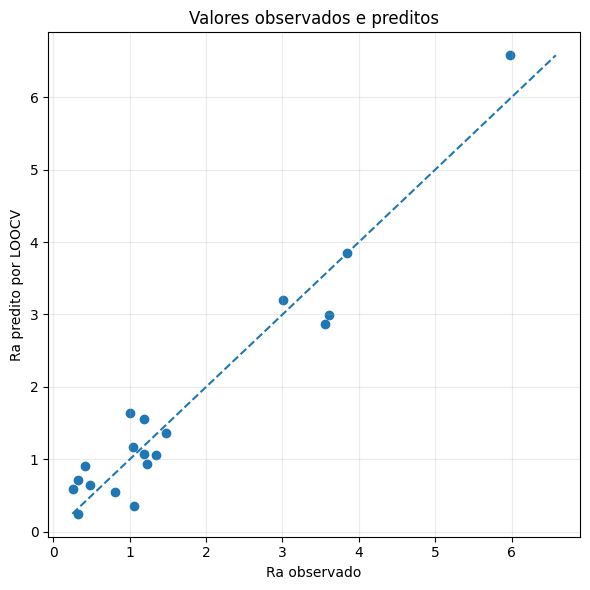

In [8]:
df_resultados = df[
    ["experiment", "a_over_b", "b_over_c", "dM", "dM_x_b_over_c", "Ra"]
].copy()

df_resultados["Ra_ajustado"] = modelo.fittedvalues
df_resultados["Ra_predito_LOOCV"] = predicoes_loocv

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df_resultados["Ra"], df_resultados["Ra_predito_LOOCV"])

limite_inferior = min(
    df_resultados["Ra"].min(),
    df_resultados["Ra_predito_LOOCV"].min(),
)
limite_superior = max(
    df_resultados["Ra"].max(),
    df_resultados["Ra_predito_LOOCV"].max(),
)

ax.plot(
    [limite_inferior, limite_superior],
    [limite_inferior, limite_superior],
    linestyle="--",
)
ax.set_xlabel("Ra observado")
ax.set_ylabel("Ra predito por LOOCV")
ax.set_title("Valores observados e preditos")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

df_resultados.to_csv(
    RESULTS_DIR / "predicoes_metodologia_resumida.csv",
    index=False,
)



## 9. Diagnósticos complementares

São reportados:

- fator de inflação da variância (VIF);
- teste de Shapiro–Wilk para os resíduos;
- teste de Breusch–Pagan para heterocedasticidade;
- distância de Cook;
- leverage.

Com apenas 19 experimentos, os testes inferenciais possuem poder limitado e devem ser interpretados em conjunto com os gráficos e o conhecimento físico do processo.


In [9]:
def calcular_vif(X_sem_constante: pd.DataFrame) -> pd.DataFrame:
    X_constante = sm.add_constant(X_sem_constante, has_constant="add")
    return pd.DataFrame({
        "variavel": X_constante.columns,
        "VIF": [
            variance_inflation_factor(X_constante.values, i)
            for i in range(X_constante.shape[1])
        ],
    })


residuos = modelo.resid
ajustados = modelo.fittedvalues

shapiro_W, shapiro_p = stats.shapiro(residuos)
bp_LM, bp_p, bp_F, bp_F_p = het_breuschpagan(residuos, X)

influencia = modelo.get_influence()
cooks_D = influencia.cooks_distance[0]
leverage = influencia.hat_matrix_diag

diagnosticos = pd.Series({
    "Shapiro_W": shapiro_W,
    "Shapiro_p": shapiro_p,
    "Breusch_Pagan_LM": bp_LM,
    "Breusch_Pagan_p": bp_p,
    "Max_Cooks_D": cooks_D.max(),
    "Max_Leverage": leverage.max(),
}, name="valor").to_frame()

display(calcular_vif(df[PREDITORES]))
display(diagnosticos)

df_influencia = df[["experiment", "Ra"]].copy()
df_influencia["Ra_ajustado"] = ajustados
df_influencia["residuo"] = residuos
df_influencia["cooks_D"] = cooks_D
df_influencia["leverage"] = leverage

display(
    df_influencia
    .sort_values("cooks_D", ascending=False)
    .head(5)
)


,variavel,VIF
0,const,9.583145
1,a_over_b,1.267621
2,dM_x_b_over_c,1.267621


,valor
Shapiro_W,0.982322
Shapiro_p,0.965819
Breusch_Pagan_LM,0.165642
Breusch_Pagan_p,0.920516
Max_Cooks_D,0.567873
Max_Leverage,0.618827


,experiment,Ra,Ra_ajustado,residuo,cooks_D,leverage
11,12,5.98,6.208938,-0.228938,0.567873,0.618827
2,3,3.56,3.130031,0.429969,0.446491,0.373107
7,8,3.61,3.085062,0.524938,0.138779,0.144796
8,9,1.06,0.418502,0.641498,0.121026,0.094742
15,16,1.00,1.592860,-0.592860,0.067964,0.066271



## 10. Teste de permutação opcional

O pipeline de validação original utiliza 5.000 permutações da resposta. A execução é deixada como opcional porque pode demorar em ambientes modestos. Para executar, altere `RUN_PERMUTATION` para `True`.


In [10]:
RUN_PERMUTATION = False
N_PERMUTACOES = 5000


def teste_permutacao_loocv(
    dados: pd.DataFrame,
    target: str,
    preditores: list[str],
    n_permutacoes: int = 5000,
    random_state: int = 42,
) -> dict:
    rng = np.random.default_rng(random_state)

    metricas_reais, _ = loocv_ols(dados, target, preditores)
    r2_perm = np.empty(n_permutacoes)
    mae_perm = np.empty(n_permutacoes)
    rmse_perm = np.empty(n_permutacoes)

    for i in range(n_permutacoes):
        dados_perm = dados.copy()
        dados_perm[target] = rng.permutation(dados[target].to_numpy())
        metricas_perm, _ = loocv_ols(dados_perm, target, preditores)

        r2_perm[i] = metricas_perm["R2_LOOCV"]
        mae_perm[i] = metricas_perm["MAE_LOOCV"]
        rmse_perm[i] = metricas_perm["RMSE_LOOCV"]

    return {
        **metricas_reais,
        "p_R2": np.mean(r2_perm >= metricas_reais["R2_LOOCV"]),
        "p_MAE": np.mean(mae_perm <= metricas_reais["MAE_LOOCV"]),
        "p_RMSE": np.mean(rmse_perm <= metricas_reais["RMSE_LOOCV"]),
    }


if RUN_PERMUTATION:
    resultado_permutacao = teste_permutacao_loocv(
        df,
        TARGET,
        PREDITORES,
        n_permutacoes=N_PERMUTACOES,
        random_state=RANDOM_STATE,
    )
    display(pd.Series(resultado_permutacao, name="valor").to_frame())
else:
    print("Teste de permutação não executado. Defina RUN_PERMUTATION = True.")


Teste de permutação não executado. Defina RUN_PERMUTATION = True.



## 11. Resultados esperados

Com a tabela processada disponibilizada no repositório, devem ser obtidos aproximadamente:

\[
\widehat{Ra}
=
-1{,}758970
+
0{,}531757\left(\frac{a}{b}\right)
+
0{,}007408
\left[
d_M\left(\frac{b}{c}\right)
\right].
\]

| Métrica | Valor esperado |
|---|---:|
| \(R^2_{\mathrm{ajustado}}\) | 0,946 |
| \(R^2_{\mathrm{LOOCV}}\) | 0,929 |
| MAE LOOCV | 0,339 |
| RMSE LOOCV | 0,404 |

Pequenas diferenças apenas na última casa decimal podem ocorrer por arredondamento da tabela publicada.



## 12. Limitações e reprodutibilidade

1. O número de experimentos é reduzido (\(n=19\)); portanto, a estabilidade do modelo deve ser analisada com validação cruzada, influência e conhecimento físico.
2. Cada experimento é resumido por um único elipsoide global. Mudanças locais ao longo do tempo não são representadas.
3. A reprodução integral desde os sinais requer a publicação dos CSVs brutos, da frequência de amostragem e do mapeamento entre arquivos e experimentos.
4. A pseudoinversa é utilizada para reduzir falhas numéricas quando a matriz de covariância está próxima da singularidade.
5. A tabela processada reproduz a regressão final, mas não substitui a disponibilização dos sinais brutos.
6. Antes da publicação pública, os autores devem confirmar as permissões de compartilhamento dos dados e das imagens experimentais.
